<div style="border-bottom: 2px solid #e8a435; padding-bottom: 16px; margin-bottom: 24px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #e8a435; font-size: 13px; font-weight: 600; letter-spacing: 0.08em; text-transform: uppercase;">Jenner Analytics &nbsp;&bull;&nbsp; Analítica de Éxito del Cliente</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #212121; font-size: 26px; font-weight: 700; margin-top: 6px;">Análisis de Causa Raíz del Abandono de Clientes</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #757575; font-size: 14px; margin-top: 4px;">Diagrama de causa y efecto PROC FISHBONE para una revisión de retención B2B SaaS de mercado medio</div>
</div>

## Resumen Ejecutivo

Este análisis organiza los factores de causa raíz del elevado abandono de clientes SaaS en un diagrama estructurado de causa y efecto (Ishikawa). El segmento B2B de mercado medio está abandonando a aproximadamente el 18% anual frente a un objetivo del 8%. Veinte hallazgos de causa raíz — extraídos de encuestas de salida, entrevistas del equipo de éxito del cliente y atribución de cohortes — se agrupan en seis categorías de causa y se representan con `PROC FISHBONE` como un diagrama de 27 nodos (un efecto, seis espinas de categoría, veinte subcausas).

El desglose complementario de `PROC MEANS` muestra dónde se concentra el abandono atribuible. **Producto** tiene la mayor cantidad de hallazgos (5 causas, 48.1 puntos de impacto total), seguido de **Precios** (4 causas, 42.3) y **Soporte** (4 causas, 40.2). Medido por impacto promedio *por causa*, **Competencia** es la categoría más severa (media 11.8), y el hallazgo individual de mayor impacto en general es el aumento de renovación de **Precios** sin aviso previo (14.2). La vista de Pareto de `PROC SGPLOT` clasifica cada causa individual para que el liderazgo pueda ver sobre qué espinas actuar primero. El entregable alimenta la revisión trimestral de retención de Éxito del Cliente.

## Fuentes de Datos

| Fuente | Descripción | Registros |
|--------|-------------|--------|
| WORK.CHURN_RCA | Hallazgos de causa raíz de abandono de clientes consolidados a partir del análisis de encuestas de salida y la retrospectiva del equipo de CS; cada fila es una causa con su categoría, evidencia de respaldo y participación estimada de impacto en el abandono | 20 |

---

In [1]:
/* --------------------------------------------------------
   Hallazgos de causa raíz de abandono de clientes (RCA)
   Plataforma SaaS, segmento B2B de mercado medio.
   Cada fila: categoría de causa, la causa específica, una
   nota de subcausa/evidencia de respaldo, y la participación
   estimada de abandono atribuible a ella (a partir de encuestas
   de salida y atribución de cohortes).
   -------------------------------------------------------- */
DATOS work.churn_rca;
    INFILE DATALINES dlm='|' dsd truncover;
    ENTRADA category :$20. cause :$90. subcause :$120. churn_impact_pct;
    DATALINES;
Producto|Brechas de funciones clave frente a competidores empresariales|Exportación masiva y límites de tasa de API citados en el 34% de las encuestas de salida|12.4
Producto|Capacidades de generación de informes limitadas|Sin generador de paneles personalizados en el nivel estándar|9.8
Producto|La app móvil va por detrás de la funcionalidad web|3 flujos de trabajo clave que los usuarios solo-móvil no pueden completar|8.2
Producto|Cambios frecuentes de interfaz sin aviso previo|Usuarios avanzados afectados por rediseños trimestrales|7.6
Producto|Brechas en el mercado de integraciones|Faltan conectores nativos de Salesforce y HubSpot|10.1
Precios|Aumento de precio de renovación sin aviso previo|Aumento del 18% en MRR con 30 días de aviso|14.2
Precios|El modelo por asiento penaliza el crecimiento del equipo|El costo se duplica cuando el equipo crece de 10 a 20|11.3
Precios|El descuento inicial no es renovable|Sorpresa de precio en la primera renovación|9.7
Precios|Sin incentivo de contrato multianual|El precio anual es idéntico al mensual|7.1
Soporte|El tiempo de primera respuesta supera las 24 horas|El objetivo del nivel es 4 horas|10.8
Soporte|Brecha de calidad en el soporte de fin de semana|La cobertura offshore carece de conocimiento del producto|9.3
Soporte|Sin CSM dedicado por debajo del nivel Enterprise|Las cuentas del mercado medio no tienen contacto asignado|11.5
Soporte|Ruta de escalamiento poco clara para los clientes|El 38% de las cuentas perdidas citó confusión sobre el escalamiento|8.6
Incorporación|El tiempo de valor supera los 90 días|La complejidad de implementación no se reveló antes de la venta|12.9
Incorporación|Documentación de autoservicio desactualizada|Última actualización hace 11 meses|8.1
Incorporación|Sin recorridos guiados en la app para funciones nuevas|Adopción de funciones por debajo del 30% a los 6 meses|9.4
Competencia|Competidor con precio 30% menor|Tres cuentas importantes citaron un competidor específico|13.1
Competencia|El competidor ofrece precios de asientos ilimitados|Elimina la penalización por asiento para equipos en crecimiento|10.6
Relación|Rotación de patrocinador ejecutivo sin gestionar|El patrocinador se fue; sin programa de reenganche|11.7
Relación|Cadencia de QBR reducida a anual|Reducción de recursos del equipo de CS hace 18 meses|9.2
;
EJECUTAR;



NOTE: DATA work.churn_rca

NOTE: Processing inline DATALINES (20 lines)

NOTE: Read 20 rows from DATALINES.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Base: concentración del impacto de abandono por categoría RCA.
   La suma muestra dónde se agrupa el abandono atribuible; el
   máximo señala la peor causa individual en cada categoría.
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.churn_rca n sum mean MAX maxdec=1;
    CLASE category;
    VAR churn_impact_pct;
    ETIQUETA category='Categoría' churn_impact_pct='Porcentaje de Impacto de Abandono';
    TÍTULO 'RCA de Abandono de Clientes: Porcentaje de Impacto por Categoría';
EJECUTAR;


                            RCA de Abandono de Clientes: Porcentaje de Impacto por Categoría                            

                                                  The MEANS Procedure

                         Analysis Variable : churn_impact_pct Porcentaje de Impacto de Abandono

        Categoría               N Obs            Sum           Mean        Maximum
        --------------------------------------------------------------------------
        Competencia                 2           23.7           11.8           13.1
        Incorporación               3           30.4           10.1           12.9
        Precios                     4           42.3           10.6           14.2
        Producto                    5           48.1            9.6           12.4
        Relación                    2           20.9           10.4           11.7
        Soporte                     4           40.2           10.1           11.5
        --------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                            RCA de Abandono de Clientes: Porcentaje de Impacto por Categoría                            




NOTE: PROC SORT data=work.churn_rca

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 20 rows from work.churn_rca.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.churn_rca

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


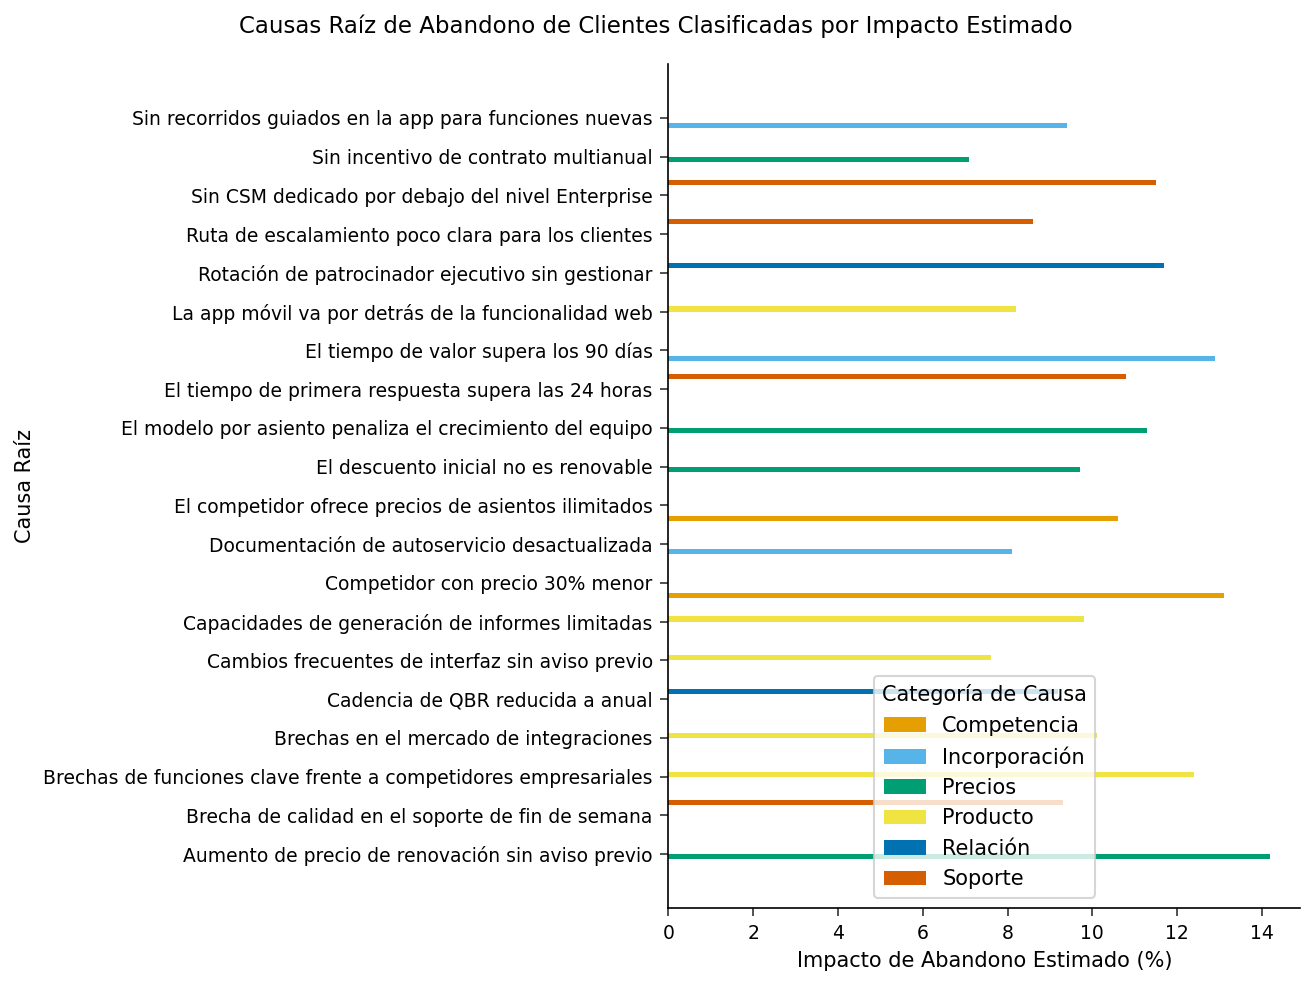

In [3]:
/* --------------------------------------------------------
   Vista de Pareto: causas raíz individuales clasificadas por
   impacto de abandono estimado, coloreadas por categoría. Esto
   complementa el fishbone al cuantificar cuáles espinas importan más.
   -------------------------------------------------------- */
PROCEDIMIENTO ORDENAR DATOS=work.churn_rca;
    POR DESCENDENTE churn_impact_pct;
EJECUTAR;

PROCEDIMIENTO SGPLOT DATOS=work.churn_rca;
    HBAR cause / RESPONSE=churn_impact_pct
        GROUP=category;
    XAXIS LABEL='Impacto de Abandono Estimado (%)';
    YAXIS LABEL='Causa Raíz' discreteorder=data;
    keylegend / TITLE='Categoría de Causa' position=bottom;
    TÍTULO 'Causas Raíz de Abandono de Clientes Clasificadas por Impacto Estimado';
EJECUTAR;


---

### Diagrama de causa y efecto (Ishikawa)

`PROC FISHBONE` construye el diagrama directamente a partir de `WORK.CHURN_RCA`: cada `category` distinta se convierte en una espina principal desde la columna vertebral central, y los hallazgos individuales de `cause` cuelgan de su espina de categoría como subcausas. El procedimiento imprime la estructura completa de causa y efecto a continuación — el efecto en la cabeza, las seis espinas de categoría, y cada subcausa agrupada bajo su espina — y escribe el gráfico fishbone correspondiente en disco. El gráfico de Pareto clasificado de arriba es la vista complementaria que cuantifica cuál de estas espinas lleva más abandono atribuible.

In [4]:
/* --------------------------------------------------------
   PROC FISHBONE: diagrama de causa y efecto del abandono de
   clientes. El diagrama se genera directamente a partir de
   WORK.CHURN_RCA, así que las seis categorías de causa y sus
   causas son exactamente los hallazgos analizados arriba.
   CATEGORY forma las espinas principales; CAUSE cuelga como
   subcausas de cada espina.
   -------------------------------------------------------- */
PROCEDIMIENTO fishbone DATOS=work.churn_rca;
    cause category / subcause=cause;
    effect 'Abandono Elevado de Clientes (18% anual frente a un objetivo del 8%)';
    TÍTULO 'Análisis de Causa Raíz del Abandono de Clientes - Segmento de Mercado Medio';
    footnote 'Fuentes: encuestas de salida, entrevistas del equipo de CS, atribución de cohortes';
EJECUTAR;


                            RCA de Abandono de Clientes: Porcentaje de Impacto por Categoría                            


                    Análisis de Causa Raíz del Abandono de Clientes - Segmento de Mercado Medio
                    The FISHBONE Procedure

  Cause-and-Effect Diagram

  [EFFECT] Abandono Elevado de Clientes (18% anual frente a un objetivo del 8%)
    [CAUSE] Precios (top)
      [SUB] Aumento de precio de renovación sin aviso previo
      [SUB] El modelo por asiento penaliza el crecimiento del equipo
      [SUB] El descuento inicial no es renovable
      [SUB] Sin incentivo de contrato multianual
    [CAUSE] Competencia (top)
      [SUB] Competidor con precio 30% menor
      [SUB] El competidor ofrece precios de asientos ilimitados
    [CAUSE] Incorporación (top)
      [SUB] El tiempo de valor supera los 90 días
      [SUB] Sin recorridos guiados en la app para funciones nuevas
      [SUB] Documentación de autoservicio desactualizada
    [CAUSE] Producto (bottom)
 


NOTE: PROC FISHBONE
NOTE: PROC FISHBONE: wrote SVG to ./actual/fishbone.svg
NOTE: Output dataset has 27 nodes


---

### Interpretación

La estructura de causa y efecto y las cifras de `PROC MEANS` por categoría orientan al liderazgo hacia un pequeño número de acciones de alto impacto. Los dos hallazgos individuales más altos — el aumento de renovación de **Precios** sin aviso previo (14.2) y el hallazgo de **Competencia** de que un rival vende capacidad equivalente a un 30% menos de precio (13.1) — son ambos problemas comerciales más que de producto, lo que sugiere que la transparencia de precios y el posicionamiento competitivo son las palancas más urgentes a corto plazo. El tiempo de valor de **Incorporación** que supera los 90 días (12.9) es el mayor hallazgo del lado de servicio y se vincula directamente con la fijación de expectativas antes de la venta.

Por volumen, **Producto** domina el diagrama (5 de 20 hallazgos, 48.1 puntos de impacto total), pero sus hallazgos son individualmente más pequeños (media 9.6) que los de **Competencia** (media 11.8) o **Precios** (media 10.6) — un recordatorio de que una larga lista de brechas de producto no es automáticamente la máxima prioridad. La espina de **Relación** (rotación de patrocinador ejecutivo y cadencia de QBR reducida, 20.9 combinados) representa cambios de proceso que el equipo de CS puede implementar dentro del trimestre actual sin inversión en producto o precios, ofreciendo la vía más rápida hacia una mejora medible en retención. La lista completa clasificada en el gráfico de Pareto permite al equipo de liderazgo secuenciar las intervenciones por impacto estimado en lugar de por tamaño de categoría.

---

In [5]:
/* --------------------------------------------------------
   Exportar los hallazgos de RCA de abandono para el mazo de
   revisión de estrategia
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.churn_rca
    OUTFILE='hallazgos_rca_abandono_clientes.csv'
    DBMS=csv REPLACE;
EJECUTAR;


NOTE: PROC EXPORT data=work.churn_rca outfile=hallazgos_rca_abandono_clientes.csv

NOTE: Exported 20 rows to hallazgos_rca_abandono_clientes.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desarrollado por <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>